# Laboratorio: Gaussian Mixture Models

**Pregunta:** ¿qué estructura encontramos entre observaciones sin usar etiquetas como respuesta? En Iris cada fila es una flor y las cuatro medidas (cm) describen sépalos y pétalos. El mismo proceso se extiende luego a erupciones de Old Faithful y a clientes mayoristas.

**Ruta:** problema → datos → exploración → variables → escala → modelo → experimentación → selección → evaluación → perfiles → interpretación.


## Objetivos de aprendizaje

- Explicar componentes gaussianos y probabilidades posteriores.
- Preparar variables y justificar decisiones sin recurrir a la clase conocida.
- Comparar configuraciones, perfilar grupos en unidades originales y reconocer límites de la evaluación interna.


## 1. Problema y método

En aprendizaje no supervisado no conocemos el grupo correcto de cada fila. Las etiquetas botánicas de Iris se reservan únicamente como contraste descriptivo al final: no se utilizan para elegir variables, entrenar ni seleccionar el número de grupos.

GMM modela una mezcla de distribuciones. Cada observación recibe probabilidades posteriores para todos los componentes; BIC compara ajuste con complejidad (menor es mejor).


## 2. Configuración y datos

Importamos solo las herramientas que utiliza este método. Fijamos una semilla para los algoritmos con inicialización aleatoria.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

RANDOM_STATE = 42
plt.style.use('seaborn-v0_8-whitegrid')
from sklearn.mixture import GaussianMixture


### Comprensión de Iris

Revisamos tamaño, tipos, faltantes, duplicados y rango de las mediciones. Una fila es una flor; no usamos `target` en la matriz de entrenamiento.

In [2]:
iris = load_iris(as_frame=True)
df = iris.data.copy()
y_reference = iris.target.copy()
display(df.head())
print("Filas y columnas:", df.shape)
print("Faltantes:", df.isna().sum().to_dict())
print("Duplicados:", df.duplicated().sum())
display(df.describe().round(2))


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


Filas y columnas: (150, 4)
Faltantes: {'sepal length (cm)': 0, 'sepal width (cm)': 0, 'petal length (cm)': 0, 'petal width (cm)': 0}
Duplicados: 1


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20
std,0.83,0.44,1.77,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


**Lectura:** las variables miden centímetros, pero tienen rangos y dispersión distintos. Comprobar faltantes y duplicados antes del ajuste evita que decisiones implícitas alteren las distancias. Un duplicado puede ser una medición genuina, por lo que aquí no se elimina automáticamente.

## 3. Exploración y elección de variables

Visualizamos longitud y ancho de pétalo como una proyección interpretable de dos dimensiones. El entrenamiento utilizará las cuatro mediciones; la gráfica no determina la partición.

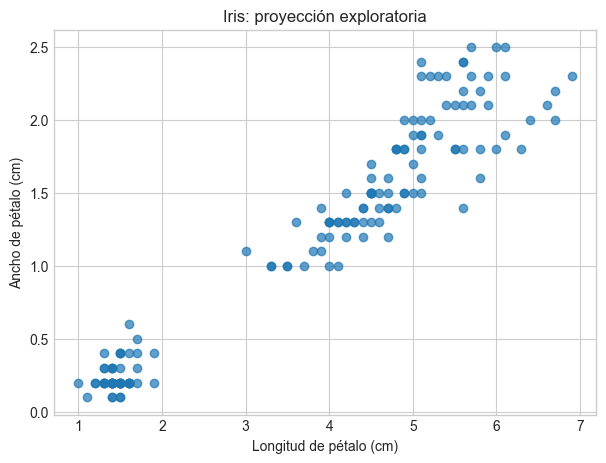

In [3]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df['petal length (cm)'], df['petal width (cm)'], alpha=.7)
ax.set(xlabel='Longitud de pétalo (cm)', ylabel='Ancho de pétalo (cm)', title='Iris: proyección exploratoria')
plt.show()


**Lectura:** se observa una zona de pétalos pequeños y otra con mayor solapamiento. Esta vista parcial no demuestra que existan exactamente dos o tres grupos en el espacio de cuatro variables.

### Variables para el modelo

Conservamos las cuatro medidas continuas porque describen dimensiones morfológicas relevantes; excluimos el nombre de especie y cualquier identificador. La correlación puede hacer que dos medidas relacionadas tengan más peso conjunto; analizaremos esa limitación.

In [4]:
features = list(df.columns)
X = df[features].copy()
display(X.corr().round(2))


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
sepal length (cm),1.00,-0.12,0.87,0.82
sepal width (cm),-0.12,1.00,-0.43,-0.37
petal length (cm),0.87,-0.43,1.00,0.96
petal width (cm),0.82,-0.37,0.96,1.00


## 4. Representación para el modelo

Como el método depende de distancias o covarianzas, estandarizamos cada medida. Conservamos `X` original para interpretar posteriormente los grupos en centímetros.

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=features, index=X.index)
display(X_scaled_df.describe().loc[['mean', 'std']].round(2))


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
mean,-0.0,-0.0,-0.0,-0.0
std,1.0,1.0,1.0,1.0


## 5. Modelo inicial y asignación probabilística

K-Means entrega una asignación rígida; GMM produce probabilidades posteriores. Probamos tres componentes y covarianza completa para observar las asignaciones inciertas.

In [6]:
initial_model = GaussianMixture(n_components=3, covariance_type='full', reg_covar=1e-6, random_state=RANDOM_STATE)
initial_model.fit(X_scaled)
initial_labels = initial_model.predict(X_scaled)
initial_probabilities = initial_model.predict_proba(X_scaled)
display(pd.DataFrame(initial_probabilities[:8], columns=['P(C0)', 'P(C1)', 'P(C2)']).round(3))


,P(C0),P(C1),P(C2)
0,0.0,1.0,0.0
1,0.0,1.0,0.0
2,0.0,1.0,0.0
3,0.0,1.0,0.0
4,0.0,1.0,0.0
5,0.0,1.0,0.0
6,0.0,1.0,0.0
7,0.0,1.0,0.0


## 6. Experimento: AIC y BIC

Ambos criterios equilibran ajuste y complejidad; valores menores son preferibles en la misma muestra. BIC penaliza más los parámetros adicionales. Probamos 1–8 componentes con covarianza `full` fija; silhouette solo se calcula cuando hay al menos dos grupos no degenerados.
**Métricas complementarias:** Calinski–Harabasz compara separación y dispersión (mayor suele indicar mejor separación); Davies–Bouldin resume semejanza entre grupos (menor suele ser mejor). Ambas favorecen ciertas geometrías y deben leerse junto a tamaños, perfiles y el objetivo del análisis. En GMM no reemplazan AIC/BIC: solo describen la partición rígida derivada de las probabilidades.


In [7]:
results = []
for k in range(1, 9):
    model = GaussianMixture(n_components=k, covariance_type='full', reg_covar=1e-6, random_state=RANDOM_STATE)
    model.fit(X_scaled)
    labels = model.predict(X_scaled)
    silhouette = silhouette_score(X_scaled, labels) if 1 < len(np.unique(labels)) < len(labels) else np.nan
    results.append({'k': k, 'aic': model.aic(X_scaled), 'bic': model.bic(X_scaled), 'silhouette': silhouette, 'calinski_harabasz': calinski_harabasz_score(X_scaled, labels) if np.isfinite(silhouette) else np.nan, 'davies_bouldin': davies_bouldin_score(X_scaled, labels) if np.isfinite(silhouette) else np.nan})
results = pd.DataFrame(results)
display(results.round(3))


,k,aic,bic,silhouette,calinski_harabasz,davies_bouldin
0,1,1008.520,1050.669,NaN,NaN,NaN
1,2,707.401,794.709,0.582,251.349,0.593
2,3,708.723,841.191,0.475,141.231,0.887
3,4,671.673,849.301,0.231,138.895,1.322
4,5,678.751,901.538,0.173,127.160,1.330
5,6,700.662,968.609,0.190,138.190,1.384
6,7,642.153,955.259,0.065,84.372,1.703
7,8,667.804,1026.069,0.174,105.189,1.481


### Análisis gráfico de configuraciones — Iris

Comparamos las curvas de K/componentes para detectar mejoras que se estabilizan, máximos o mínimos. Las escalas de los criterios son distintas: cada métrica tiene su propio eje. AIC/BIC admiten K=1; los índices basados en separación empiezan en K=2. El gráfico orienta la selección; perfiles y estabilidad completan la interpretación.

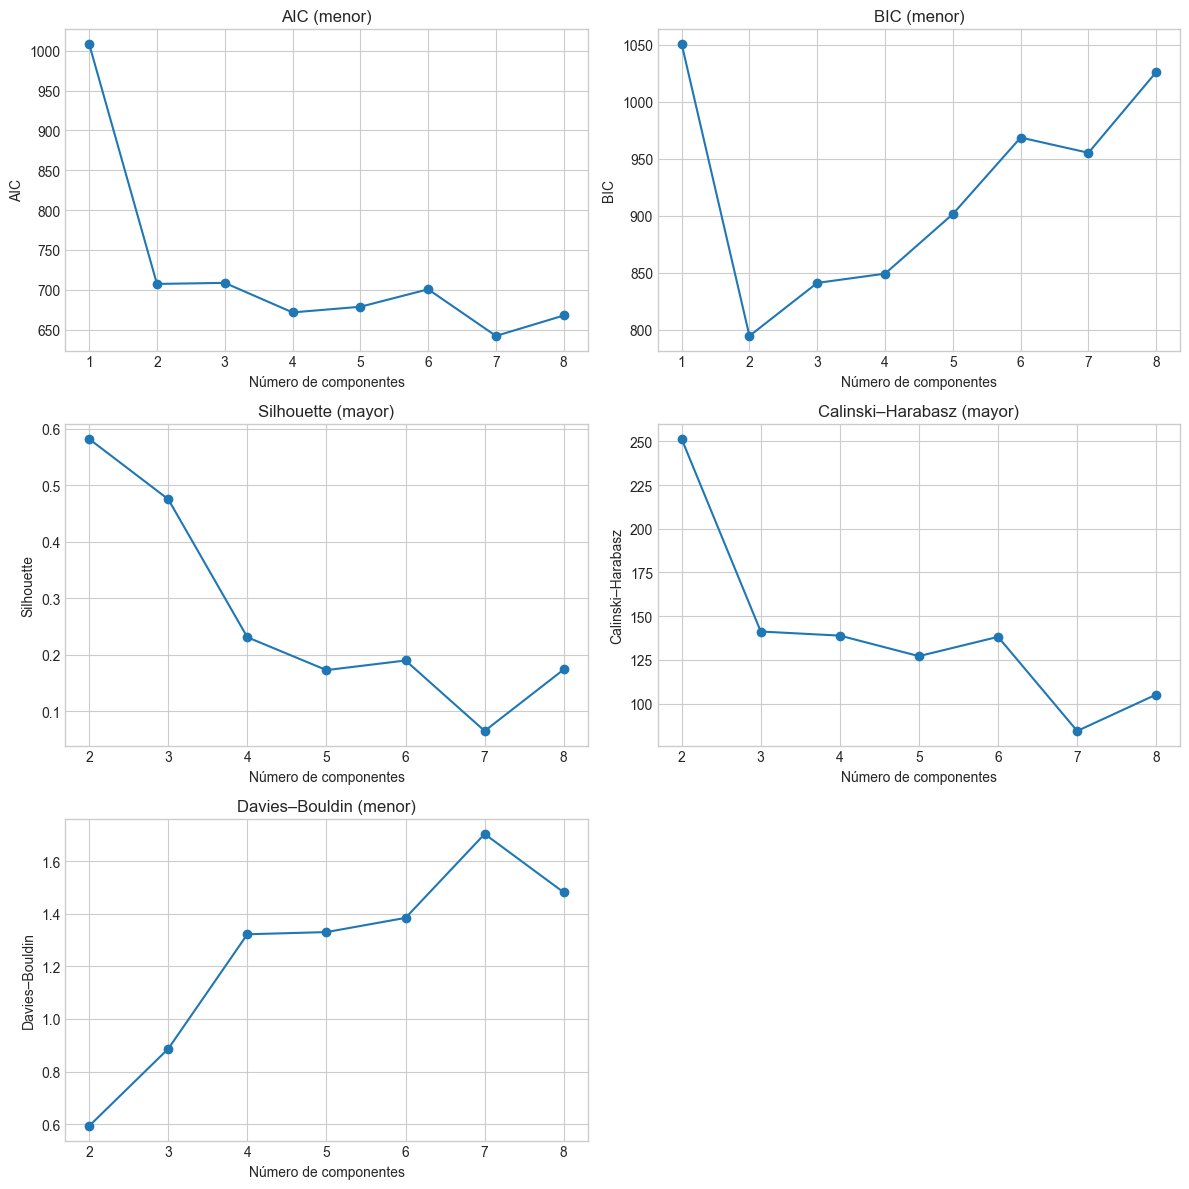

In [8]:
fig, axes = plt.subplots(3, 2, figsize=(12, 12))
axes = np.ravel(axes)
axes[0].plot(results['k'], results['aic'], marker='o')
axes[0].set(xlabel='Número de componentes', ylabel='AIC', title='AIC (menor)')
axes[1].plot(results['k'], results['bic'], marker='o')
axes[1].set(xlabel='Número de componentes', ylabel='BIC', title='BIC (menor)')
axes[2].plot(results['k'], results['silhouette'], marker='o')
axes[2].set(xlabel='Número de componentes', ylabel='Silhouette', title='Silhouette (mayor)')
axes[3].plot(results['k'], results['calinski_harabasz'], marker='o')
axes[3].set(xlabel='Número de componentes', ylabel='Calinski–Harabasz', title='Calinski–Harabasz (mayor)')
axes[4].plot(results['k'], results['davies_bouldin'], marker='o')
axes[4].set(xlabel='Número de componentes', ylabel='Davies–Bouldin', title='Davies–Bouldin (menor)')
axes[5].axis('off')
plt.tight_layout(); plt.show()


**Lectura:** identifica si las métricas coinciden en una configuración o señalan compromisos diferentes. Un óptimo en una curva describe este espacio de variables y esta muestra; comprueba tamaños y perfiles antes de interpretar los grupos.

## 7. Selección de configuración

Seleccionamos un candidato por el criterio declarado; contrastaremos tamaño, perfiles y plausibilidad antes de darle significado. Una métrica interna no valida que los grupos sean entidades naturales.

In [9]:
selected_k = int(results.loc[results.bic.idxmin(), 'k'])
print('Componentes candidatos por BIC:', selected_k)


Componentes candidatos por BIC: 2


## 8. Ajuste y evaluación final

Ajustamos el candidato usando la misma representación estandarizada. Los números de grupo son identificadores arbitrarios. Las métricas se calculan sobre las variables usadas en el ajuste.

In [10]:
final_model = GaussianMixture(n_components=selected_k, covariance_type='full', reg_covar=1e-6, random_state=RANDOM_STATE)
final_model.fit(X_scaled)
labels = final_model.predict(X_scaled)
probabilities = final_model.predict_proba(X_scaled)
print('BIC final:', round(final_model.bic(X_scaled), 2))
print('Asignaciones con probabilidad máxima < 0.8:', int((probabilities.max(axis=1) < .8).sum()))
display(pd.DataFrame(probabilities[:8]).round(3))


BIC final: 794.71
Asignaciones con probabilidad máxima < 0.8: 0


,0,1
0,0.0,1.0
1,0.0,1.0
2,0.0,1.0
3,0.0,1.0
4,0.0,1.0
5,0.0,1.0
6,0.0,1.0
7,0.0,1.0


## 9. Proyección para visualizar

Mostramos dos medidas de pétalo originales, aunque el ajuste utilizó las cuatro variables. El solapamiento aquí no describe necesariamente la separación en cuatro dimensiones.

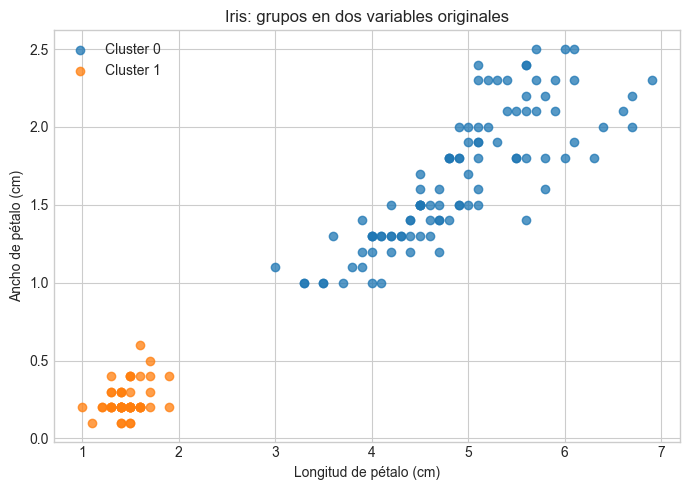

In [11]:
plot_df = df.copy()
plot_df['cluster'] = labels
fig, ax = plt.subplots(figsize=(7, 5))
for cluster, part in plot_df.groupby('cluster'):
    ax.scatter(part['petal length (cm)'], part['petal width (cm)'], label=f'Cluster {cluster}', alpha=.75)
ax.set(xlabel='Longitud de pétalo (cm)', ylabel='Ancho de pétalo (cm)', title='Iris: grupos en dos variables originales')
ax.legend(); plt.tight_layout(); plt.show()


## 10. Perfiles e interpretación

Volvemos a las medidas originales para describir los grupos en centímetros. Comparamos tamaños y medias; las especies conocidas se cruzan al final como referencia externa, nunca como criterio de ajuste o selección.

In [12]:
profile = plot_df.groupby('cluster')[features].agg(['mean', 'median']).round(2)
sizes = plot_df.groupby('cluster').size().rename('n')
display(sizes)
display(profile)
display(pd.crosstab(plot_df['cluster'], y_reference.rename('especie_codificada')))


cluster
0    100
1     50
Name: n, dtype: int64

sepal length (cm)        sepal width (cm)        petal length (cm)  \
                     mean median             mean median              mean   
cluster                                                                      
0                    6.26    6.3             2.87    2.9              4.91   
1                    5.01    5.0             3.43    3.4              1.46   

               petal width (cm)         
        median             mean median  
cluster                                 
0          4.9             1.68    1.6  
1          1.5             0.25    0.2

especie_codificada,0,1,2
cluster,,,
0,0,50,50
1,50,0,0


### Síntesis basada en los resultados

Identificamos extremos de longitud de pétalo sin asumir que el número de cluster expresa un orden. La tabla de medias permite comprobar la afirmación en el resultado calculado.

In [13]:
petal_means = plot_df.groupby('cluster')['petal length (cm)'].mean()
print(f'Cluster con menor longitud media de pétalo: {petal_means.idxmin()} ({petal_means.min():.2f} cm)')
print(f'Cluster con mayor longitud media de pétalo: {petal_means.idxmax()} ({petal_means.max():.2f} cm)')


Cluster con menor longitud media de pétalo: 1 (1.46 cm)
Cluster con mayor longitud media de pétalo: 0 (4.91 cm)


## 11. Ejercicio 2 — Old Faithful: erupciones del géiser

**Pregunta:** ¿se distinguen comportamientos de erupción por duración (minutos) y tiempo de espera hasta la siguiente erupción (minutos)? Cada fila es un episodio; no existe etiqueta de cluster. Fuente: dataset `faithful` de R, publicado por Rdatasets. Este ejercicio repite el workflow completo con dos variables observables. Requiere acceso a la fuente CSV.


### Datos y exploración

Comprobamos registros, ausencias y escalas. Una dispersión en unidades originales permite reconocer estructura preliminar sin asignar grupos.

Dimensiones: (272, 2) Nulos: {'eruptions': 0, 'waiting': 0}


,eruptions,waiting
0,3.600,79
1,1.800,54
2,3.333,74
3,2.283,62
4,4.533,85


,eruptions,waiting
count,272.00,272.00
mean,3.49,70.90
std,1.14,13.59
min,1.60,43.00
25%,2.16,58.00
50%,4.00,76.00
75%,4.45,82.00
max,5.10,96.00


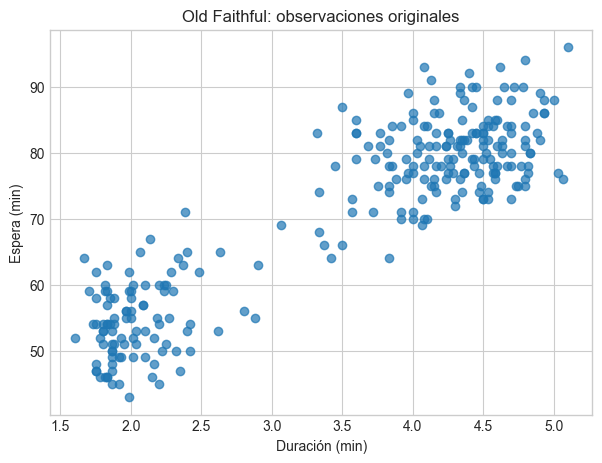

In [14]:
faithful_url = 'https://vincentarelbundock.github.io/Rdatasets/csv/datasets/faithful.csv'
faithful = pd.read_csv(faithful_url).drop(columns='rownames')
print('Dimensiones:', faithful.shape, 'Nulos:', faithful.isna().sum().to_dict())
display(faithful.head())
display(faithful.describe().round(2))
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(faithful.eruptions, faithful.waiting, alpha=.7)
ax.set(xlabel='Duración (min)', ylabel='Espera (min)', title='Old Faithful: observaciones originales')
plt.show()


### Selección de variables y preparación

Ambas mediciones son relevantes; omitimos el índice del archivo. La distancia o covarianza se estima con variables estandarizadas. Los perfiles volverán a minutos originales.

In [15]:
faithful_features = ['eruptions', 'waiting']
faithful_X = faithful[faithful_features].copy()
faithful_scaler = StandardScaler()
faithful_scaled = faithful_scaler.fit_transform(faithful_X)
display(pd.DataFrame(faithful_scaled, columns=faithful_features).describe().loc[['mean', 'std']].round(2))


,eruptions,waiting
mean,0.0,0.0
std,1.0,1.0


### Componentes y selección probabilística

AIC y BIC comparan ajuste y complejidad para 1–8 gaussianas; BIC (menor es mejor) propone un número de componentes, con covarianza completa fija.
**Métricas complementarias:** Calinski–Harabasz compara separación y dispersión (mayor suele indicar mejor separación); Davies–Bouldin resume semejanza entre grupos (menor suele ser mejor). Ambas favorecen ciertas geometrías y deben leerse junto a tamaños, perfiles y el objetivo del análisis. En GMM no reemplazan AIC/BIC: solo describen la partición rígida derivada de las probabilidades.


In [16]:
faithful_scores = []
for k in range(1, 9):
    model = GaussianMixture(n_components=k, covariance_type='full', reg_covar=1e-6, random_state=RANDOM_STATE)
    model.fit(faithful_scaled)
    candidate_labels = model.predict(faithful_scaled)
    valid_partition = 1 < len(np.unique(candidate_labels)) < len(candidate_labels)
    faithful_scores.append({'k': k, 'aic': model.aic(faithful_scaled), 'bic': model.bic(faithful_scaled), 'silhouette': silhouette_score(faithful_scaled, candidate_labels) if valid_partition else np.nan, 'calinski_harabasz': calinski_harabasz_score(faithful_scaled, candidate_labels) if valid_partition else np.nan, 'davies_bouldin': davies_bouldin_score(faithful_scaled, candidate_labels) if valid_partition else np.nan})
faithful_scores = pd.DataFrame(faithful_scores)
display(faithful_scores.round(2))


,k,aic,bic,silhouette,calinski_harabasz,davies_bouldin
0,1,1099.99,1118.02,NaN,NaN,NaN
1,2,792.92,832.59,0.75,1574.55,0.34
2,3,798.06,859.36,0.46,1060.13,0.91
3,4,797.49,880.42,0.46,922.88,0.86
4,5,781.11,885.67,0.29,777.00,1.28
5,6,783.93,910.13,0.31,752.90,1.16
6,7,796.93,944.76,0.34,872.87,0.96
7,8,804.64,974.11,0.35,904.57,0.90


### Análisis gráfico de configuraciones — Old Faithful

Comparamos las curvas de K/componentes para detectar mejoras que se estabilizan, máximos o mínimos. Las escalas de los criterios son distintas: cada métrica tiene su propio eje. AIC/BIC admiten K=1; los índices basados en separación empiezan en K=2. El gráfico orienta la selección; perfiles y estabilidad completan la interpretación.

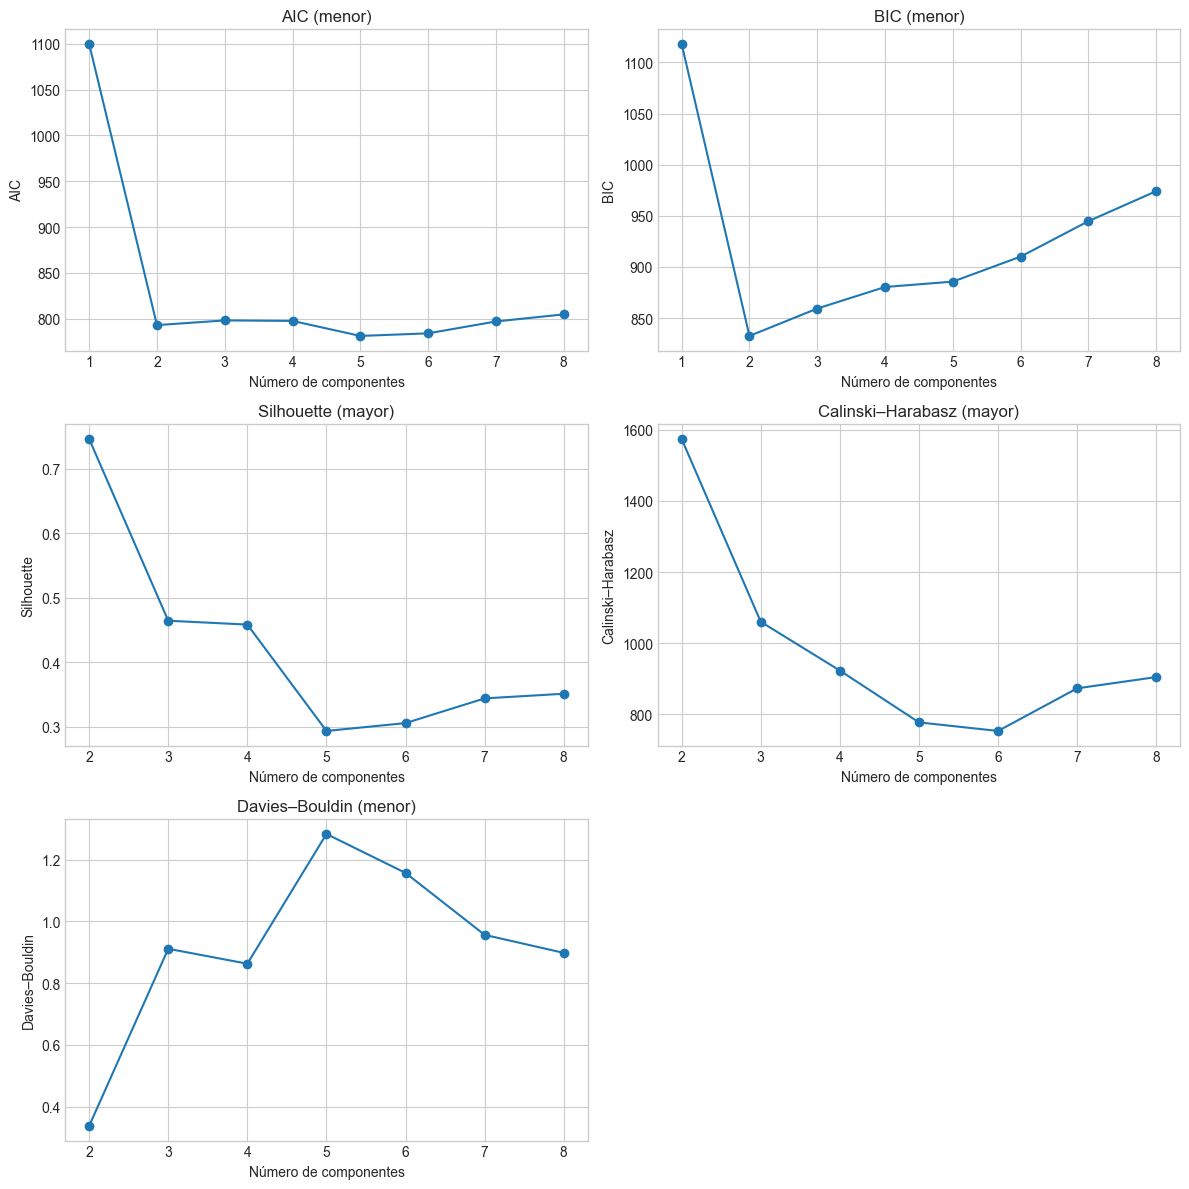

In [17]:
fig, axes = plt.subplots(3, 2, figsize=(12, 12))
axes = np.ravel(axes)
axes[0].plot(faithful_scores['k'], faithful_scores['aic'], marker='o')
axes[0].set(xlabel='Número de componentes', ylabel='AIC', title='AIC (menor)')
axes[1].plot(faithful_scores['k'], faithful_scores['bic'], marker='o')
axes[1].set(xlabel='Número de componentes', ylabel='BIC', title='BIC (menor)')
axes[2].plot(faithful_scores['k'], faithful_scores['silhouette'], marker='o')
axes[2].set(xlabel='Número de componentes', ylabel='Silhouette', title='Silhouette (mayor)')
axes[3].plot(faithful_scores['k'], faithful_scores['calinski_harabasz'], marker='o')
axes[3].set(xlabel='Número de componentes', ylabel='Calinski–Harabasz', title='Calinski–Harabasz (mayor)')
axes[4].plot(faithful_scores['k'], faithful_scores['davies_bouldin'], marker='o')
axes[4].set(xlabel='Número de componentes', ylabel='Davies–Bouldin', title='Davies–Bouldin (menor)')
axes[5].axis('off')
plt.tight_layout(); plt.show()


**Lectura:** identifica si las métricas coinciden en una configuración o señalan compromisos diferentes. Un óptimo en una curva describe este espacio de variables y esta muestra; comprueba tamaños y perfiles antes de interpretar los grupos.

### Configuración candidata y ajuste final

Aplicamos el criterio principal explicado arriba y ajustamos el modelo final. Este valor es una decisión para el laboratorio y puede revisarse si los perfiles resultan inestables o poco útiles.

In [18]:
faithful_k = int(faithful_scores.loc[faithful_scores.bic.idxmin(), 'k'])
faithful_model = GaussianMixture(n_components=faithful_k, covariance_type='full', reg_covar=1e-6, random_state=RANDOM_STATE)
faithful_model.fit(faithful_scaled)
faithful_labels = faithful_model.predict(faithful_scaled)
faithful_probs = faithful_model.predict_proba(faithful_scaled)
print('Componentes:', faithful_k, 'Asignaciones < 0.8:', int((faithful_probs.max(axis=1)<.8).sum()))
display(pd.DataFrame(faithful_probs[:5]).round(3))


Componentes: 2 Asignaciones < 0.8: 0


,0,1
0,1.0,0.0
1,0.0,1.0
2,1.0,0.0
3,0.0,1.0
4,1.0,0.0


### Visualización, perfil y lectura

El gráfico usa las dos variables modeladas; los promedios y tamaños originales permiten describir erupciones cortas o largas sin atribuir significado ordinal a los identificadores.

eruptions       waiting
             size  mean    mean
cluster                        
0             175  4.29   79.99
1              97  2.04   54.49

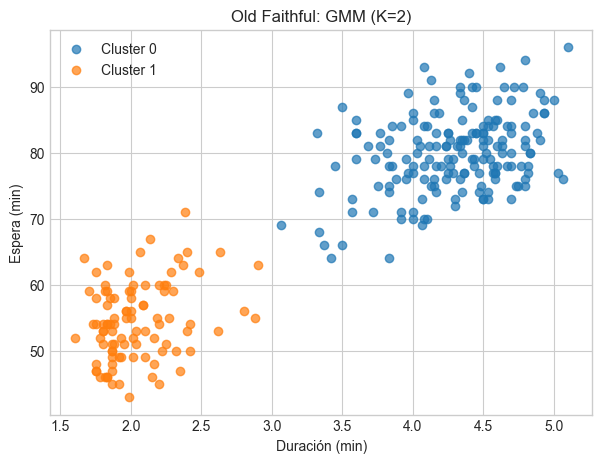

Grupo de menor duración media: 1


In [19]:
faithful_profile = faithful.copy()
faithful_profile['cluster'] = faithful_labels
display(faithful_profile.groupby('cluster').agg({'eruptions':['size', 'mean'], 'waiting':'mean'}).round(2))
fig, ax = plt.subplots(figsize=(7, 5))
for cluster, part in faithful_profile.groupby('cluster'):
    ax.scatter(part.eruptions, part.waiting, label=f'Cluster {cluster}', alpha=.7)
ax.set(xlabel='Duración (min)', ylabel='Espera (min)', title=f'Old Faithful: GMM (K={faithful_k})')
ax.legend(); plt.show()
print('Grupo de menor duración media:', faithful_profile.groupby('cluster').eruptions.mean().idxmin())


**Conclusión guiada:** identifica en la tabla qué grupo tiene la duración y la espera media mayores. Valora si hay solapamiento en el gráfico y si la solución responde a la pregunta; ningún algoritmo garantiza que los regímenes de erupción sean categorías naturales.

## 12. Ejercicio 3 — Wholesale Customers: segmentos de gasto

**Pregunta:** ¿existen patrones de gasto anual entre clientes mayoristas? Cada fila es un cliente y las seis categorías de gasto son las variables del modelo. `Channel` y `Region` describen segmentos después del ajuste; no son etiquetas de entrenamiento. Fuente: UCI Machine Learning Repository, dataset 292. Se usa su CSV público; requiere conexión de red.


### Datos y exploración

Comprobamos esquema, ausencias y asimetría antes de decidir transformaciones. Las magnitudes originales se conservan para perfilado.

In [20]:
wholesale_url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00292/Wholesale%20customers%20data.csv'
wholesale = pd.read_csv(wholesale_url)
spend_features = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']
print('Dimensiones:', wholesale.shape, 'Nulos:', wholesale.isna().sum().to_dict())
display(wholesale.head())
display(wholesale[spend_features].describe().round(1))


Dimensiones: (440, 8) Nulos: {'Channel': 0, 'Region': 0, 'Fresh': 0, 'Milk': 0, 'Grocery': 0, 'Frozen': 0, 'Detergents_Paper': 0, 'Delicassen': 0}


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.0,440.0,440.0,440.0,440.0,440.0
mean,12000.3,5796.3,7951.3,3071.9,2881.5,1524.9
std,12647.3,7380.4,9503.2,4854.7,4767.9,2820.1
min,3.0,55.0,3.0,25.0,3.0,3.0
25%,3127.8,1533.0,2153.0,742.2,256.8,408.2
50%,8504.0,3627.0,4755.5,1526.0,816.5,965.5
75%,16933.8,7190.2,10655.8,3554.2,3922.0,1820.2
max,112151.0,73498.0,92780.0,60869.0,40827.0,47943.0


### Variables y transformación

Excluimos `Channel` y `Region` del ajuste. `log1p` reduce el peso de gastos extremos sin descartar clientes; después escalamos las seis variables. La distancia del modelo se calcula en este espacio transformado.

In [21]:
wholesale_X = wholesale[spend_features].copy()
wholesale_log = np.log1p(wholesale_X)
wholesale_scaler = StandardScaler()
wholesale_scaled = wholesale_scaler.fit_transform(wholesale_log)
display(wholesale_log.describe().loc[['mean', 'std']].round(2))


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
mean,8.73,8.12,8.44,7.30,6.79,6.67
std,1.47,1.08,1.11,1.28,1.71,1.29


### Componentes, AIC/BIC y probabilidades

La comparación mantiene covarianza completa y datos fijos. Analizamos incertidumbre posterior de pertenencia además del perfil de gasto.
**Métricas complementarias:** Calinski–Harabasz compara separación y dispersión (mayor suele indicar mejor separación); Davies–Bouldin resume semejanza entre grupos (menor suele ser mejor). Ambas favorecen ciertas geometrías y deben leerse junto a tamaños, perfiles y el objetivo del análisis. En GMM no reemplazan AIC/BIC: solo describen la partición rígida derivada de las probabilidades.


In [22]:
wholesale_scores = []
for k in range(1, 9):
    model = GaussianMixture(n_components=k, covariance_type='full', reg_covar=1e-6, random_state=RANDOM_STATE)
    model.fit(wholesale_scaled)
    candidate_labels = model.predict(wholesale_scaled)
    valid_partition = 1 < len(np.unique(candidate_labels)) < len(candidate_labels)
    wholesale_scores.append({'k': k, 'aic': model.aic(wholesale_scaled), 'bic': model.bic(wholesale_scaled), 'silhouette': silhouette_score(wholesale_scaled, candidate_labels) if valid_partition else np.nan, 'calinski_harabasz': calinski_harabasz_score(wholesale_scaled, candidate_labels) if valid_partition else np.nan, 'davies_bouldin': davies_bouldin_score(wholesale_scaled, candidate_labels) if valid_partition else np.nan})
wholesale_scores = pd.DataFrame(wholesale_scores)
display(wholesale_scores.round(2))


,k,aic,bic,silhouette,calinski_harabasz,davies_bouldin
0,1,6485.94,6596.28,NaN,NaN,NaN
1,2,6209.59,6434.36,0.27,165.42,1.39
2,3,6103.28,6442.48,0.11,78.12,2.01
3,4,5863.48,6317.11,0.17,80.70,2.40
4,5,5862.47,6430.53,0.15,60.72,2.48
5,6,5862.50,6544.99,0.18,58.75,2.23
6,7,5841.23,6638.15,0.13,49.68,2.55
7,8,5776.39,6687.74,0.14,54.82,2.01


### Análisis gráfico de configuraciones — Wholesale Customers

Comparamos las curvas de K/componentes para detectar mejoras que se estabilizan, máximos o mínimos. Las escalas de los criterios son distintas: cada métrica tiene su propio eje. AIC/BIC admiten K=1; los índices basados en separación empiezan en K=2. El gráfico orienta la selección; perfiles y estabilidad completan la interpretación.

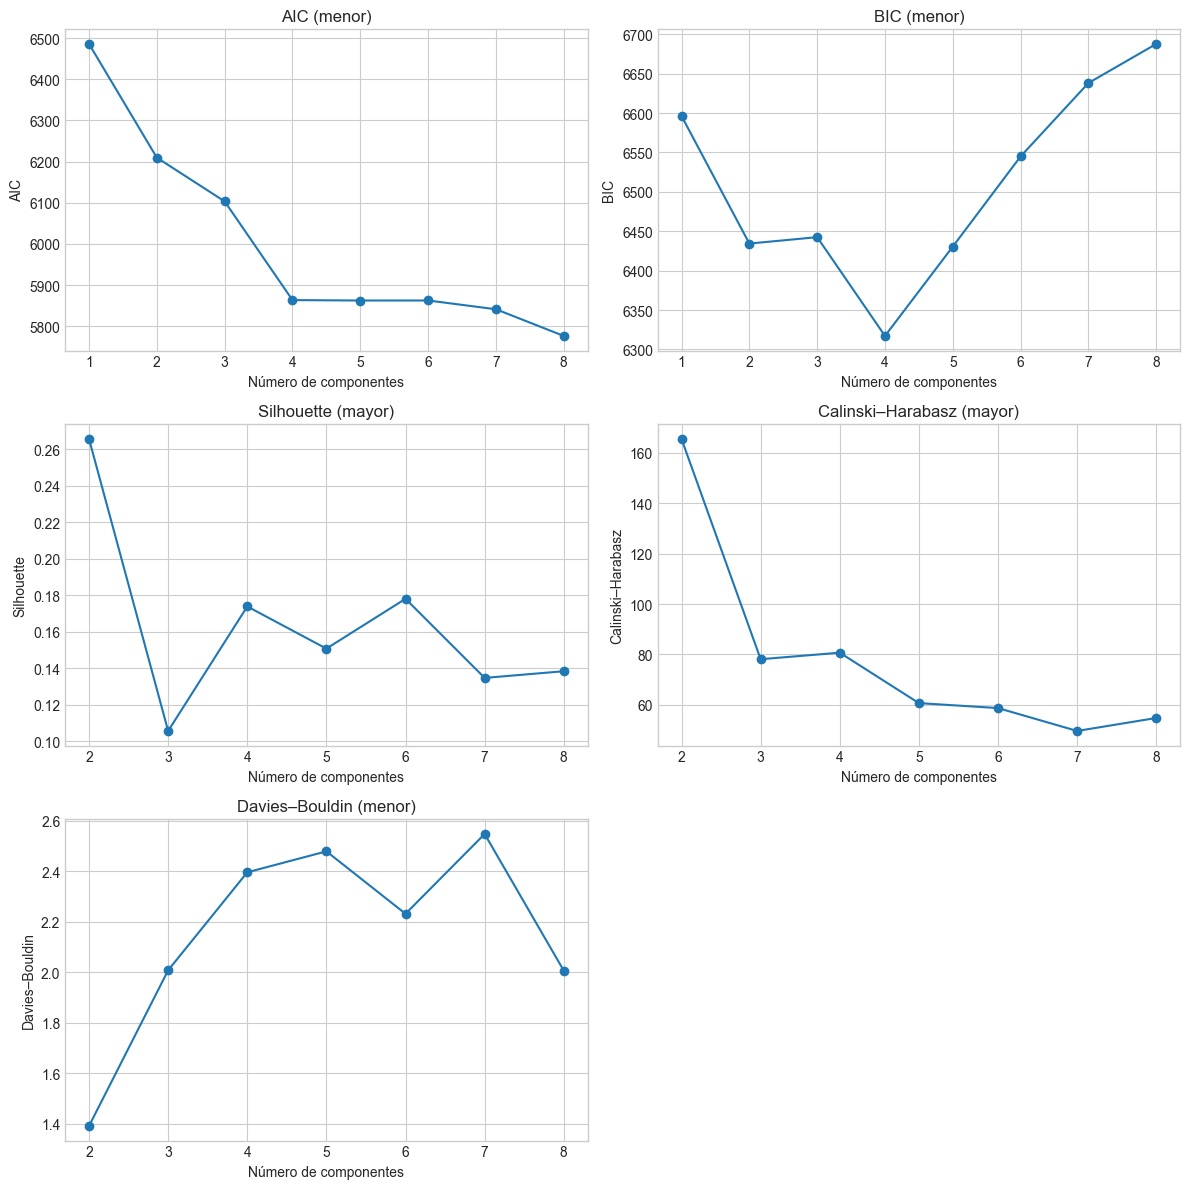

In [23]:
fig, axes = plt.subplots(3, 2, figsize=(12, 12))
axes = np.ravel(axes)
axes[0].plot(wholesale_scores['k'], wholesale_scores['aic'], marker='o')
axes[0].set(xlabel='Número de componentes', ylabel='AIC', title='AIC (menor)')
axes[1].plot(wholesale_scores['k'], wholesale_scores['bic'], marker='o')
axes[1].set(xlabel='Número de componentes', ylabel='BIC', title='BIC (menor)')
axes[2].plot(wholesale_scores['k'], wholesale_scores['silhouette'], marker='o')
axes[2].set(xlabel='Número de componentes', ylabel='Silhouette', title='Silhouette (mayor)')
axes[3].plot(wholesale_scores['k'], wholesale_scores['calinski_harabasz'], marker='o')
axes[3].set(xlabel='Número de componentes', ylabel='Calinski–Harabasz', title='Calinski–Harabasz (mayor)')
axes[4].plot(wholesale_scores['k'], wholesale_scores['davies_bouldin'], marker='o')
axes[4].set(xlabel='Número de componentes', ylabel='Davies–Bouldin', title='Davies–Bouldin (menor)')
axes[5].axis('off')
plt.tight_layout(); plt.show()


**Lectura:** identifica si las métricas coinciden en una configuración o señalan compromisos diferentes. Un óptimo en una curva describe este espacio de variables y esta muestra; comprueba tamaños y perfiles antes de interpretar los grupos.

### Configuración candidata y ajuste final

Aplicamos el criterio principal explicado arriba y ajustamos el modelo final. Este valor es una decisión para el laboratorio y puede revisarse si los perfiles resultan inestables o poco útiles.

In [24]:
wholesale_k = int(wholesale_scores.loc[wholesale_scores.bic.idxmin(), 'k'])
wholesale_model = GaussianMixture(n_components=wholesale_k, covariance_type='full', reg_covar=1e-6, random_state=RANDOM_STATE)
wholesale_model.fit(wholesale_scaled)
wholesale_labels = wholesale_model.predict(wholesale_scaled)
wholesale_probs = wholesale_model.predict_proba(wholesale_scaled)
print('Componentes candidatos:', wholesale_k, 'Asignaciones < 0.8:', int((wholesale_probs.max(axis=1)<.8).sum()))
display(pd.DataFrame(wholesale_probs[:5]).round(3))


Componentes candidatos: 4 Asignaciones < 0.8: 56


,0,1,2,3
0,0.972,0.008,0.014,0.006
1,0.023,0.014,0.963,0.001
2,0.018,0.015,0.965,0.002
3,0.000,0.993,0.000,0.007
4,0.000,0.275,0.722,0.003


### Perfiles de negocio

Se agrupan los **gastos originales** y se comparan Channel y Region después del ajuste. Cada número de grupo es arbitrario; los cruces descriptivos no demuestran causas.

In [25]:
wholesale_profile = wholesale.copy()
wholesale_profile['cluster'] = wholesale_labels
display(wholesale_profile.groupby('cluster')[spend_features].agg(['mean', 'median']).round(1))
display(wholesale_profile.groupby('cluster').size().rename('clientes'))
display(pd.crosstab(wholesale_profile.cluster, wholesale_profile.Channel, normalize='index').round(2))
display(pd.crosstab(wholesale_profile.cluster, wholesale_profile.Region, normalize='index').round(2))


Fresh             Milk          Grocery           Frozen          \
            mean   median    mean  median     mean   median    mean  median   
cluster                                                                       
0         4439.4   1531.0  9389.4  7704.0  15917.5  12822.0   691.7   333.0   
1        14946.1  10650.0  3103.1  2003.0   3206.0   2442.0  4428.1  2569.0   
2        11193.1   8090.0  9697.0  6721.0  14033.0  10790.0  1811.7  1336.0   
3        10991.5   3572.5  4730.9  2042.5   5534.3   3711.5  2949.6   926.0   

        Detergents_Paper         Delicassen          
                    mean  median       mean  median  
cluster                                              
0                 7482.9  5980.0     1166.3   710.0  
1                  532.7   354.0     1345.4   921.5  
2                 6061.0  4314.0     1973.8  1519.0  
3                  501.7   173.5     1849.9   359.5

cluster
0     67
1    218
2    103
3     52
Name: clientes, dtype: int64

Channel,1,2
cluster,,
0,0.16,0.84
1,0.97,0.03
2,0.25,0.75
3,0.96,0.04


Region,1,2,3
cluster,,,
0,0.12,0.12,0.76
1,0.22,0.11,0.68
2,0.14,0.10,0.77
3,0.15,0.12,0.73


### Distribuciones por cluster: boxplots de gasto

Cada panel compara la mediana, dispersión y valores extremos de una categoría de gasto entre clusters. Mostramos `log1p(gasto)` solo para visualizar distribuciones muy asimétricas; las tablas previas mantienen el gasto original. La escala horizontal identifica el cluster y la vertical la categoría transformada. Una diferencia de medias puede deberse a unos pocos clientes extremos: contrastamos siempre con mediana y caja.


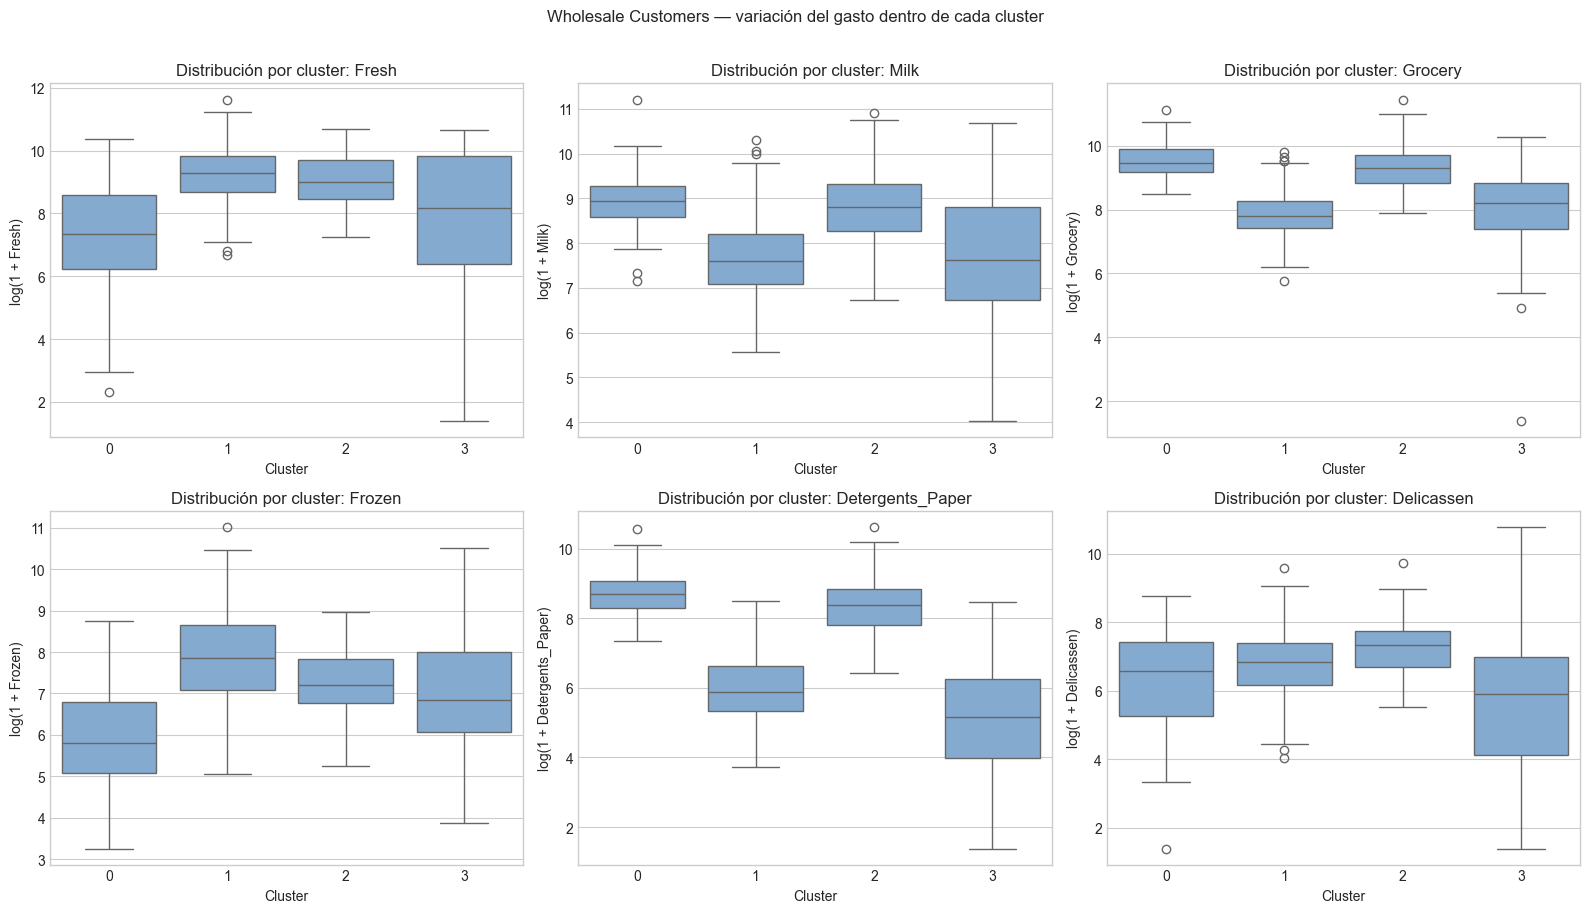

In [26]:
wholesale_plot = wholesale_profile[['cluster'] + spend_features].copy()
wholesale_plot[spend_features] = np.log1p(wholesale_plot[spend_features])
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, feature in zip(axes.flat, spend_features):
    sns.boxplot(data=wholesale_plot, x='cluster', y=feature, ax=ax, color='#77aadd', showfliers=True)
    ax.set(xlabel='Cluster', ylabel=f'log(1 + {feature})', title=f'Distribución por cluster: {feature}')
fig.suptitle('Wholesale Customers — variación del gasto dentro de cada cluster', y=1.01)
plt.tight_layout(); plt.show()


**Lectura de los boxplots:** compara las medianas y el ancho de las cajas para cada feature; observa si algún grupo solo se diferencia por clientes extremos. Las cajas superpuestas indican que esa variable por sí sola discrimina poco, aunque el modelo use las seis variables conjuntamente.

### Densidades KDE por cluster

Las curvas suavizadas permiten comparar forma, multimodalidad y solapamiento de cada feature. Se estiman sobre `log1p(gasto)` y se normalizan **dentro de cada cluster**, de modo que la altura no representa tamaño del grupo. La suavización puede sugerir modos artificiales en clusters pequeños: contrastamos con tamaños y boxplots.


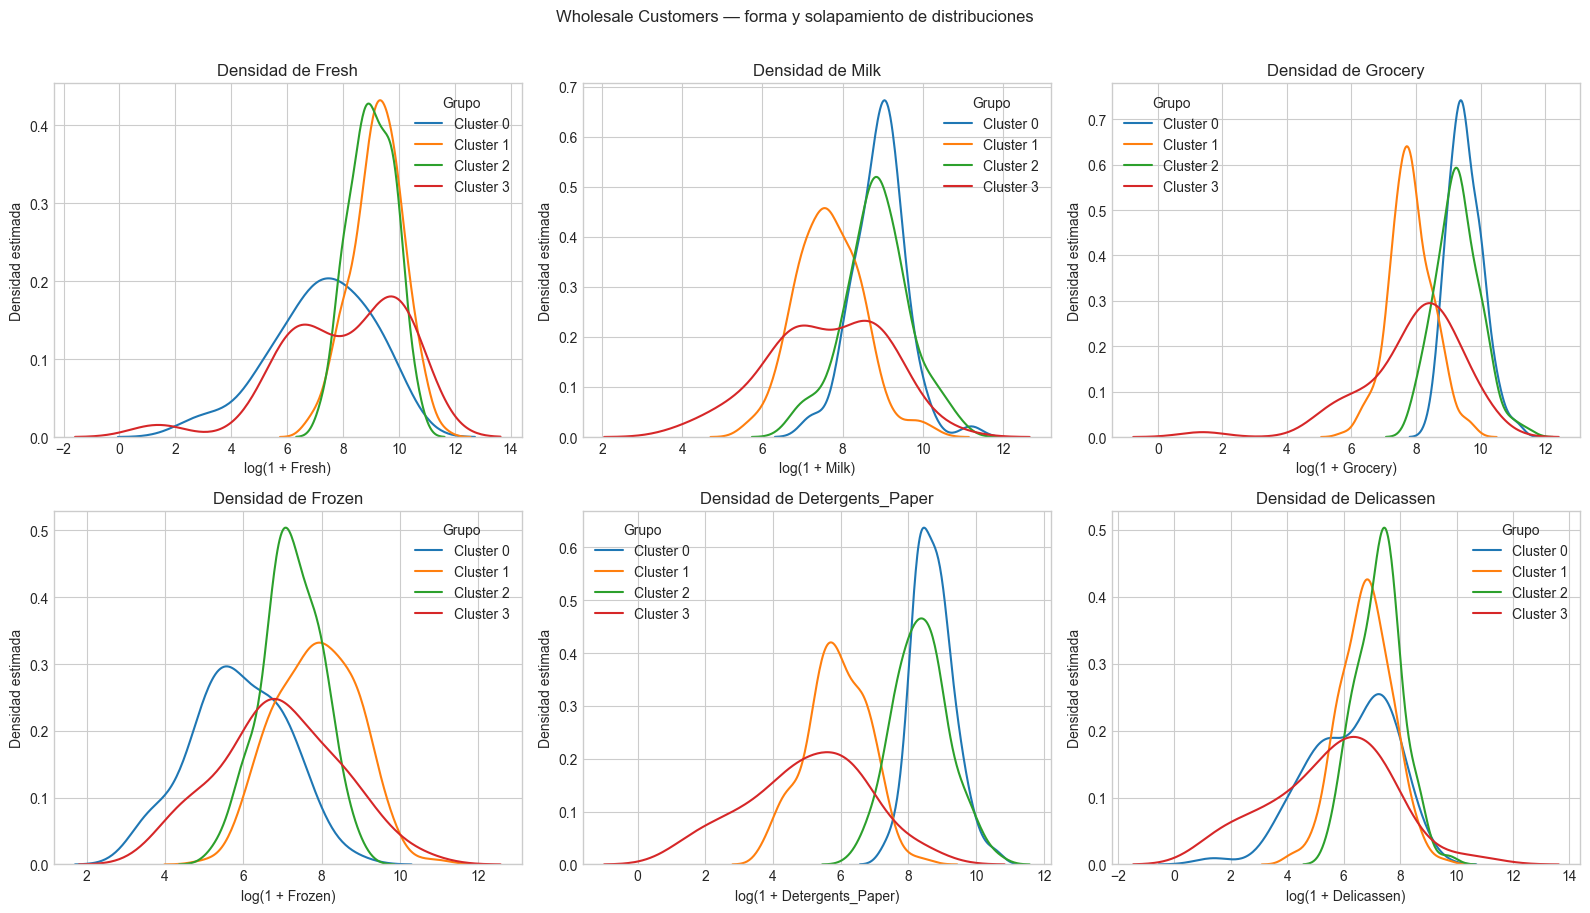

In [27]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, feature in zip(axes.flat, spend_features):
    for cluster, part in wholesale_plot.groupby('cluster'):
        values = part[feature].dropna()
        if len(values) >= 3 and values.nunique() >= 3:
            sns.kdeplot(x=values, ax=ax, label=f'Cluster {cluster}', common_norm=False, warn_singular=False)
    ax.set(xlabel=f'log(1 + {feature})', ylabel='Densidad estimada', title=f'Densidad de {feature}')
    if ax.lines:
        ax.legend(title='Grupo')
fig.suptitle('Wholesale Customers — forma y solapamiento de distribuciones', y=1.01)
plt.tight_layout(); plt.show()


**Interpretación conjunta:** usa las curvas para identificar features con densidades bien separadas y aquellas con fuerte superposición. Contrasta ese patrón con medianas, valores extremos y tamaños; una diferencia visible en una variable no implica que ella sola explique toda la asignación multivariable.


### Proyección parcial e interpretación

Mostramos Grocery y Detergents_Paper en escala log para inspección; el modelo utilizó las seis categorías. Leemos el segmento con mayor gasto medio en Grocery según el resultado real.

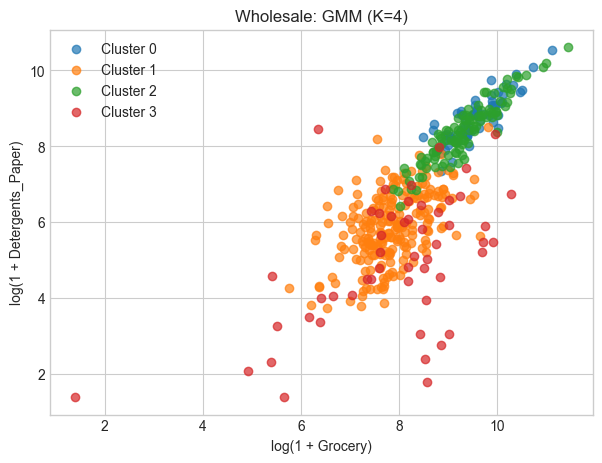

Grupo de mayor Grocery promedio: 0


In [28]:
fig, ax = plt.subplots(figsize=(7, 5))
for cluster, part in wholesale_profile.groupby('cluster'):
    ax.scatter(np.log1p(part.Grocery), np.log1p(part.Detergents_Paper), label=f'Cluster {cluster}', alpha=.7)
ax.set(xlabel='log(1 + Grocery)', ylabel='log(1 + Detergents_Paper)', title=f'Wholesale: GMM (K={wholesale_k})')
ax.legend(); plt.show()
print('Grupo de mayor Grocery promedio:', wholesale_profile.groupby('cluster').Grocery.mean().idxmax())


**Conclusión guiada:** compara proporciones de Channel y Region y el tamaño de cada grupo. Un segmento pequeño puede reflejar clientes con gasto atípico; revisa medianas además de medias antes de asignar una etiqueta comercial. El resultado depende de `log1p`, escalado, variables y configuración.

## 13. Limitaciones y conclusiones

Las probabilidades expresan incertidumbre bajo el modelo de mezcla. BIC elige entre las configuraciones probadas, sin demostrar que los datos sigan gaussianas. Inicialización, covarianza, número de componentes y soluciones casi degeneradas afectan el resultado.

Los perfiles calculados arriba identifican qué grupos tienen pétalos cortos o largos y permiten discutir si la partición responde a la pregunta inicial. No debemos atribuir causalidad ni universalidad a estas agrupaciones.


## 14. Ejercicios sin solución

1. **Conceptual:** explica qué información se pierde al observar solo dos de las cuatro medidas.
2. **Código:** repite el ajuste usando exclusivamente las dos variables de pétalo y compara los perfiles.
3. **Experimento:** compara dos configuraciones y razona cuál elegirías con métricas y tamaños.
4. **Interpretación:** redacta un perfil por grupo en unidades originales y detecta solapamientos.
5. **Transferencia:** aplica el workflow a Old Faithful o Wholesale Customers; documenta la fuente, faltantes y efecto del escalado.


## 15. Referencias y datos

- Scikit-learn: documentación de Iris, preprocesamiento y del estimador usado.
- Iris: Fisher (1936); datos disponibles mediante `sklearn.datasets.load_iris`.
- Old Faithful: `datasets::faithful` (R); fuente original utilizada: Rdatasets.
- Wholesale Customers: UCI Machine Learning Repository, conjunto 292.
